<a href="https://colab.research.google.com/github/U-ROHITH/Machine-Learning/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET LOADED
     location  sqft  rooms  price_lakhs
     Madhapur  1824      4         98.7
 Secunderabad  1528      1         63.3
 Dilsukhnagar  2636      2         92.0
   Kukatpally  1524      2         70.5
Banjara Hills  2181      4        116.3
Banjara Hills   989      3         73.5
Banjara Hills  2217      2        115.9
 Secunderabad   855      3         59.9
   Kukatpally  1308      4         71.0
 Dilsukhnagar  2438      4         89.9

Total houses : 500
Columns      : ['location', 'sqft', 'rooms', 'price_lakhs']

BASIC STATS
Avg Price    : ₹85.7 Lakhs
Min Price    : ₹35.8 Lakhs
Max Price    : ₹134.8 Lakhs
Avg Sqft     : 1837 sqft


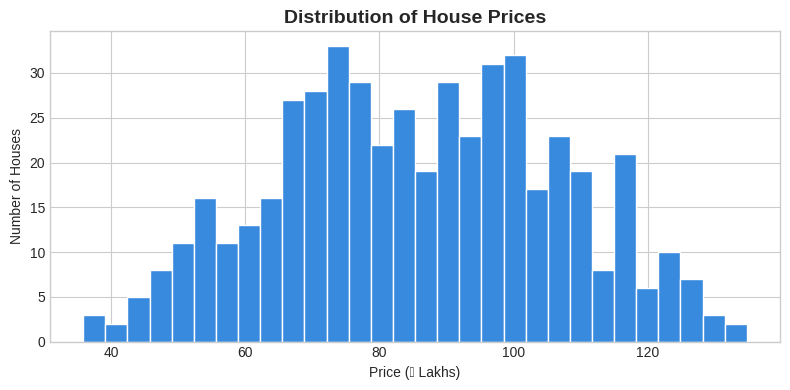

>> Most houses are priced between ₹60L and ₹110L


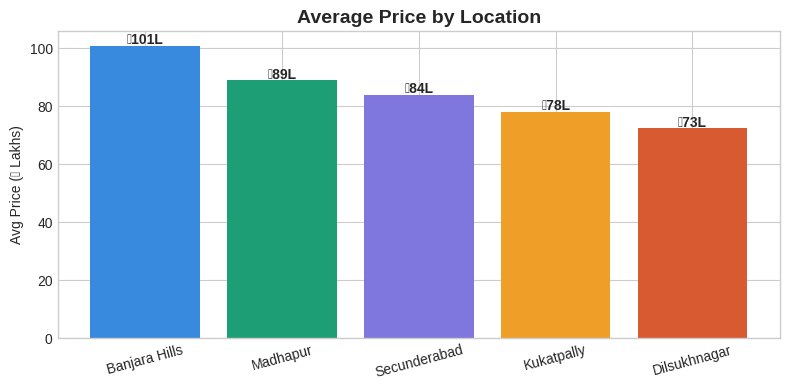

LOCATION PRICE BREAKDOWN
  Banjara Hills        ₹101 Lakhs
  Madhapur             ₹89 Lakhs
  Secunderabad         ₹84 Lakhs
  Kukatpally           ₹78 Lakhs
  Dilsukhnagar         ₹73 Lakhs


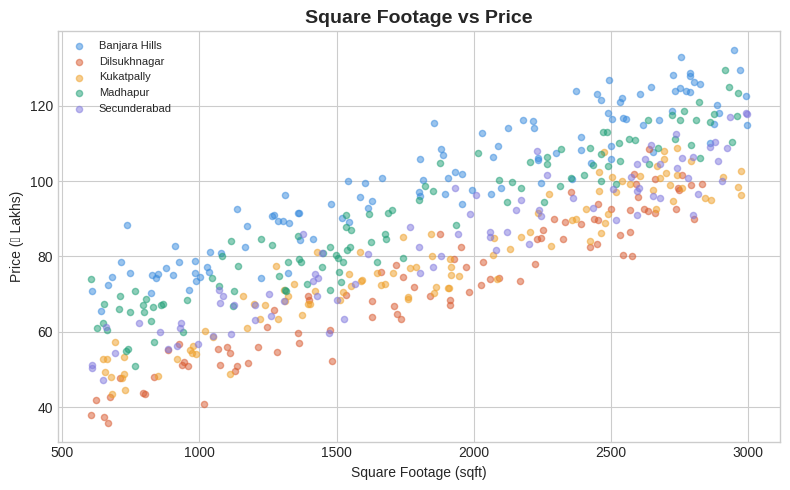

>> Bigger house = higher price. The model finds this line automatically.

PREPROCESSING
Training size : 400 houses
Test size     : 100 houses

TRAINING MODEL
Model trained successfully.

MODEL RESULTS
R² Score : 0.75  (higher is better, max = 1.0)
MAE      : ₹9.0 Lakhs  (avg prediction error)


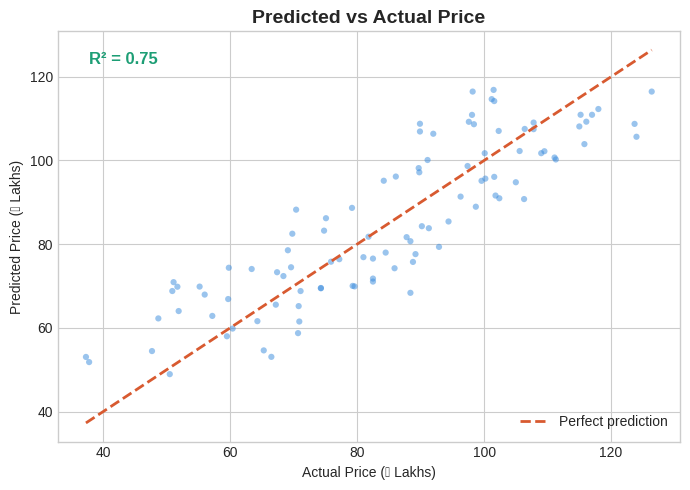

>> Dots close to the diagonal line = accurate predictions


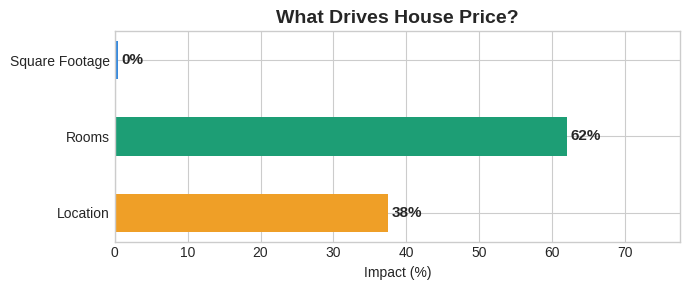

FEATURE IMPORTANCE
  Rooms                62.1%
  Location             37.5%
  Square Footage       0.4%

>> The model figured this out by itself. Nobody told it what matters.


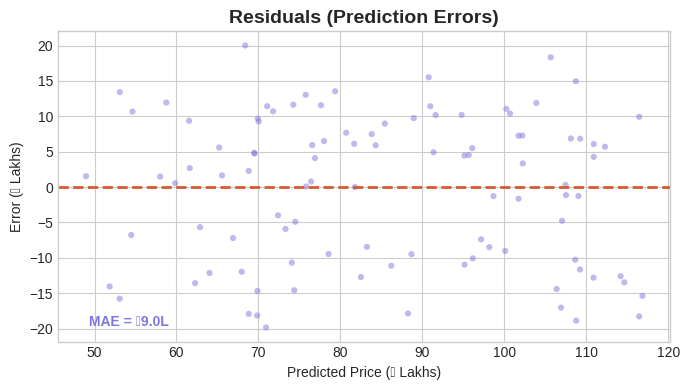

>> Errors scattered around zero = no systematic bias in predictions

LIVE PREDICTION DEMO
  Input  : 1200 sqft | 3 rooms | Madhapur
  Output : ₹69.7 Lakhs

Day 1 done. 99 to go.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv('house_prices.csv')
print("=" * 45)
print("DATASET LOADED")
print("=" * 45)
print(df.head(10).to_string(index=False))
print(f"\nTotal houses : {len(df)}")
print(f"Columns      : {list(df.columns)}")

# ── BASIC STATS ──────────────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("BASIC STATS")
print("=" * 45)
print(f"Avg Price    : ₹{df['price_lakhs'].mean():.1f} Lakhs")
print(f"Min Price    : ₹{df['price_lakhs'].min():.1f} Lakhs")
print(f"Max Price    : ₹{df['price_lakhs'].max():.1f} Lakhs")
print(f"Avg Sqft     : {df['sqft'].mean():.0f} sqft")

# ── CHART 1: Price Distribution ──────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(df['price_lakhs'], bins=30, color='#378ADD', edgecolor='white')
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (₹ Lakhs)')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.show()
print(">> Most houses are priced between ₹60L and ₹110L")

# ── CHART 2: Price by Location ───────────────────────────────────────────────
colors_map = {
    'Banjara Hills': '#378ADD', 'Madhapur': '#1D9E75',
    'Kukatpally': '#EF9F27', 'Dilsukhnagar': '#D85A30',
    'Secunderabad': '#7F77DD'
}
loc_avg = df.groupby('location')['price_lakhs'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(loc_avg.index, loc_avg.values,
        color=[colors_map[l] for l in loc_avg.index], edgecolor='none')
for i, v in enumerate(loc_avg.values):
    plt.text(i, v + 0.5, f'₹{v:.0f}L', ha='center', fontsize=10, fontweight='bold')
plt.title('Average Price by Location', fontsize=14, fontweight='bold')
plt.ylabel('Avg Price (₹ Lakhs)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print("=" * 45)
print("LOCATION PRICE BREAKDOWN")
print("=" * 45)
for loc, price in loc_avg.items():
    print(f"  {loc:<20} ₹{price:.0f} Lakhs")

# ── CHART 3: Size vs Price Scatter ───────────────────────────────────────────
plt.figure(figsize=(8, 5))
for loc, grp in df.groupby('location'):
    plt.scatter(grp['sqft'], grp['price_lakhs'],
                c=colors_map[loc], alpha=0.5, s=20, label=loc)
plt.title('Square Footage vs Price', fontsize=14, fontweight='bold')
plt.xlabel('Square Footage (sqft)')
plt.ylabel('Price (₹ Lakhs)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(">> Bigger house = higher price. The model finds this line automatically.")

# ── PREPROCESS ───────────────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("PREPROCESSING")
print("=" * 45)
le = LabelEncoder()
df['location_enc'] = le.fit_transform(df['location'])
X = df[['sqft', 'rooms', 'location_enc']]
y = df['price_lakhs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training size : {len(X_train)} houses")
print(f"Test size     : {len(X_test)} houses")

# ── TRAIN MODEL ──────────────────────────────────────────────────────────────
print("\n" + "=" * 45)
print("TRAINING MODEL")
print("=" * 45)
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully.")

# ── METRICS ──────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("\n" + "=" * 45)
print("MODEL RESULTS")
print("=" * 45)
print(f"R² Score : {r2:.2f}  (higher is better, max = 1.0)")
print(f"MAE      : ₹{mae:.1f} Lakhs  (avg prediction error)")

# ── CHART 4: Predicted vs Actual ─────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='#378ADD', alpha=0.5, s=20, edgecolors='none')
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], color='#D85A30', lw=2, linestyle='--', label='Perfect prediction')
plt.text(0.05, 0.92, f'R² = {r2:.2f}', transform=plt.gca().transAxes,
         fontsize=12, color='#1D9E75', fontweight='bold')
plt.title('Predicted vs Actual Price', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (₹ Lakhs)')
plt.ylabel('Predicted Price (₹ Lakhs)')
plt.legend()
plt.tight_layout()
plt.show()
print(">> Dots close to the diagonal line = accurate predictions")

# ── CHART 5: Feature Importance ──────────────────────────────────────────────
feature_names  = ['Square Footage', 'Rooms', 'Location']
coefficients   = np.abs(model.coef_)
importance_pct = (coefficients / coefficients.sum()) * 100

plt.figure(figsize=(7, 3))
bars = plt.barh(feature_names, importance_pct,
                color=['#378ADD', '#1D9E75', '#EF9F27'], height=0.5, edgecolor='none')
for bar, pct in zip(bars, importance_pct):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{pct:.0f}%', va='center', fontsize=11, fontweight='bold')
plt.title('What Drives House Price?', fontsize=14, fontweight='bold')
plt.xlabel('Impact (%)')
plt.xlim(0, max(importance_pct) * 1.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("=" * 45)
print("FEATURE IMPORTANCE")
print("=" * 45)
for name, pct in sorted(zip(feature_names, importance_pct), key=lambda x: -x[1]):
    print(f"  {name:<20} {pct:.1f}%")
print("\n>> The model figured this out by itself. Nobody told it what matters.")

# ── CHART 6: Residuals ───────────────────────────────────────────────────────
residuals = y_test.values - y_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, color='#7F77DD', alpha=0.5, s=20, edgecolors='none')
plt.axhline(0, color='#D85A30', lw=2, linestyle='--')
plt.title('Residuals (Prediction Errors)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Price (₹ Lakhs)')
plt.ylabel('Error (₹ Lakhs)')
plt.text(0.05, 0.05, f'MAE = ₹{mae:.1f}L', transform=plt.gca().transAxes,
         fontsize=10, color='#7F77DD', fontweight='bold')
plt.tight_layout()
plt.show()
print(">> Errors scattered around zero = no systematic bias in predictions")

# ── SINGLE PREDICTION DEMO ───────────────────────────────────────────────────
print("\n" + "=" * 45)
print("LIVE PREDICTION DEMO")
print("=" * 45)
sample    = pd.DataFrame({
    'sqft'        : [1200],
    'rooms'       : [3],
    'location_enc': [le.transform(['Madhapur'])[0]]
})
predicted = model.predict(sample)[0]
print(f"  Input  : 1200 sqft | 3 rooms | Madhapur")
print(f"  Output : ₹{predicted:.1f} Lakhs")
print("\nDay 1 done. 99 to go.")